In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
from functools import partial
from scipy.optimize import minimize
import pandas as pd
import random
import matplotlib
import pointpats

# Дополнительные главы теории вероятностей

1. Рассмотрим величину с плотностью f(x) = c/(|x| ln^2|x|) на отрезке [−1/e, 1/e]. Что говорит теория о
сходимости суммы таких величин?
Проиллюстрируем это на практике – сгенерируем выборку из сумм n таких величин при различных n.
Можем ли мы увидеть на гистограмме особенность плотности суммы?

In [27]:
def gen_x(size):
    # generate half
    # f(x) = c/(|x| ln^2|x|) на 0, 1/e
    # F(x) = 1/ln|x|
    # F^-1(x) = exp(1/x)

    r = stats.uniform.rvs(size = size)
    x = np.zeros(size)
    for i in range(size):
        u = stats.uniform.rvs()
        if u<1/2:
            x[i] = -np.exp(-1/r[i])
        else:
            x[i] = np.exp(-1/r[i])
    return x


def vary_n(n_vals = [1, 5, 10, 50, 75], num_sim = 1000000):
    for n in n_vals:
        s = np.zeros(num_sim)
        for i in range(num_sim):
            x = gen_x(size = n)
            s[i] = np.sum(x)/np.sqrt(n)
        plt.hist(s, density=True, bins = 200)
        plt.title(f'n={n}')
        plt.show()
    



Text(0.5, 1.0, 'Check X generator')

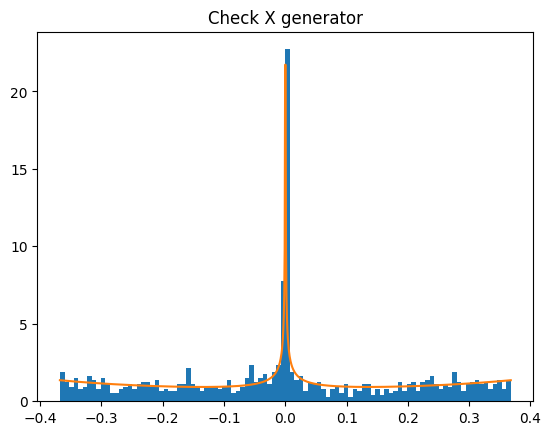

In [12]:
data = gen_x(1000)
plt.hist(data, density = True,bins = 100)
x = np.linspace(-1/np.e, 1/np.e, 1000)
plt.plot(x, 1/(2*np.abs(x)*np.log(np.abs(x))**2))
plt.title("Check X generator")

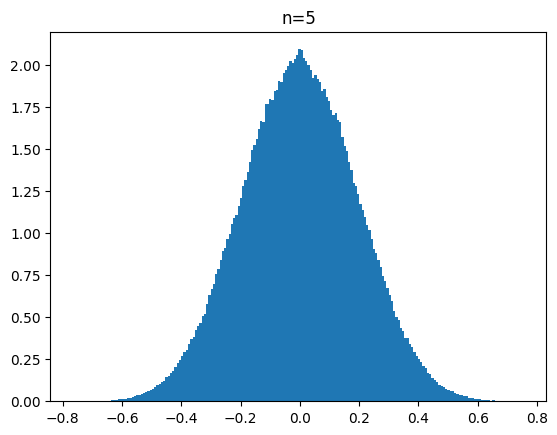

In [37]:
vary_n(n_vals = [5], num_sim = 1000000)

2. Пусть Xi – н.о.р. с распределением F размера n. Найти вероятность того, что выборка имеет сумму
Sn, большую 2nEF X для различных n, используя явный вид функции распределения из Python. Для выборок какого размера приближение из центральной предельной теоремы отклоняется вдвое от реальной вероятности в относительном смысле? Как это отражается на p-value при применении критерия Стьюдента с нормальной аппроксимацией?
Задача на бонус по дополнительным главам: получить асимптотику из теоремы Петрова о больших
уклонениях и сравнить результат с ней.

(a) F = exp(1);

(b) F = Bern(1/3).

In [6]:
def prob_exp(n):
    return 1 - stats.gamma.cdf(2*n, a=n)

def prob_bern(n):
    return 1 - stats.binom.cdf(k = 2*n/3, n =n, p =1/3)

def clt_approx_bern(n):
    return 1-stats.norm.cdf((2*n/3-n/3)/np.sqrt(n*2/9))

def clt_approx_exp(n):
    return 1-stats.norm.cdf((2*n-n)/np.sqrt(n))

def petrov_approx_exp(n):
    return 1/np.sqrt(2*np.pi*n)*np.exp(-n*(1-np.log(2)))

def petrov_approx_bern(n):
    return 3/(np.sqrt(np.pi*n)*np.log(2))*np.exp(-n*(np.log(2)/3))
    

def compare(true_prob, clt_approx,petrov_approx,  max_size = 30):
    x = range(1,max_size+1)
    err_clt = np.zeros(max_size)
    err_petrov = np.zeros(max_size)
    for n in x:
        err_clt[n-1] = true_prob(n)/clt_approx(n)
        err_petrov[n-1] = true_prob(n)/petrov_approx(n)
    plt.plot(x, err_clt, label = 'True / clt')
    plt.plot(x, err_petrov,label = 'True / Petrov')



0.02925268807696113
0.0126736593387341

0.0049954123083075785
0.0007827011290012509



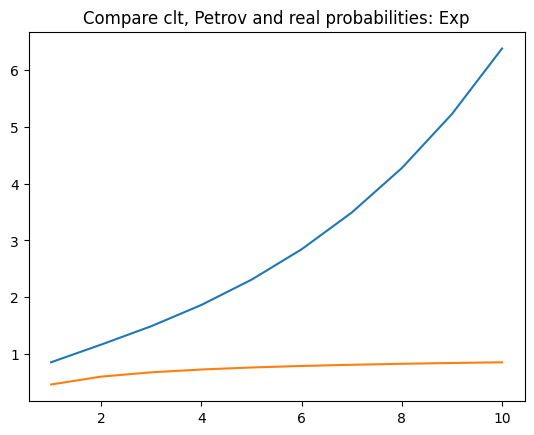

In [3]:
compare(prob_exp, clt_approx_exp, petrov_approx_exp, max_size = 10)
plt.title("Compare clt, Petrov and real probabilities: Exp")
plt.show()

In [4]:
def check_ldt_exp(a = 0.06, num_sim = 10000, n = 5):
    # large deviation theory
    acceptance = 0
    cdl = []
    true = []
    for _ in range(num_sim):
        data = stats.expon.rvs(size = n)
        mean = np.mean(data)
        cdl_pval = stats.ttest_1samp(data, 1)[1]
        true_pval = 1 - stats.gamma.cdf(mean, a = n, scale = 1/n)
        cdl.append(cdl_pval)
        true.append(true_pval)
    sns.ecdfplot(cdl, label = 'CDL approx')
    sns.ecdfplot(true ,label = 'True p-value')
    x = np.linspace(0, 1, 100)
    #plt.plot(x,x, linestyle = '--', color= 'black')
    plt.legend()
    plt.show()

        




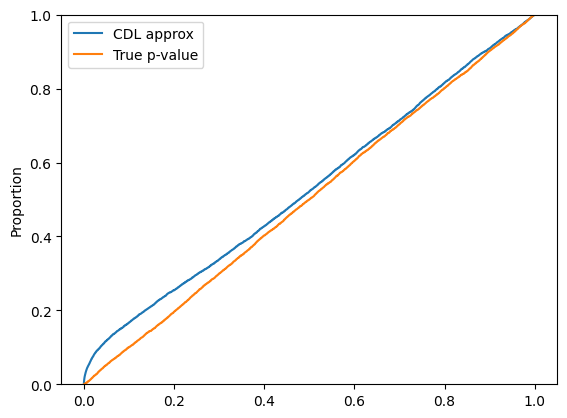

In [33]:
check_ldt_exp(a = 0.1)

Асимптотика больших уклонений при n -> inf

In [20]:
def get_asymp(num_sim = 1000):
    n_vals = [20, 30, 50, 100, 150]
    len_n = len(n_vals)
    empirical_probs = np.zeros(len_n)
    for i, n in enumerate(n_vals):
        big = 0
        for sim in range(num_sim):
            x = stats.expon.rvs(size = n)
            s = np.sum(x)
            if s > 2*n:
                big+=1/num_sim
        empirical_probs[i] = big
    theoretical_probs = [(1/np.sqrt(2*np.pi*n)*np.exp(-n*(1-np.log(2)))) for n in n_vals]
    empirical_probs = [(empirical_probs[i]) for i in range(len_n)]
    #print(empirical_probs)
    #comparison = [np.log(theoretical_probs[j]/empirical_probs[j]) for j in range(len_n)]
    plt.plot(n_vals, empirical_probs, marker='o', label = 'Empirical probs')
    plt.plot(n_vals, theoretical_probs, marker='o', label = 'Theoretical')
    #plt.plot(n_vals, comparison, marker='o', label ='ln(theory/empirical)')
    plt.legend()
    plt.title("Asympthotic behaviour from Petrov's theorem : exp")
    plt.show()

            


![опа картинка](petrov_exp.png)

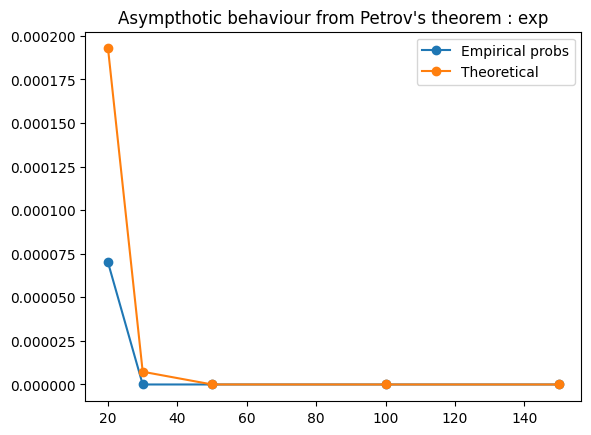

In [22]:
get_asymp(num_sim = 100000)

## Bernoulli

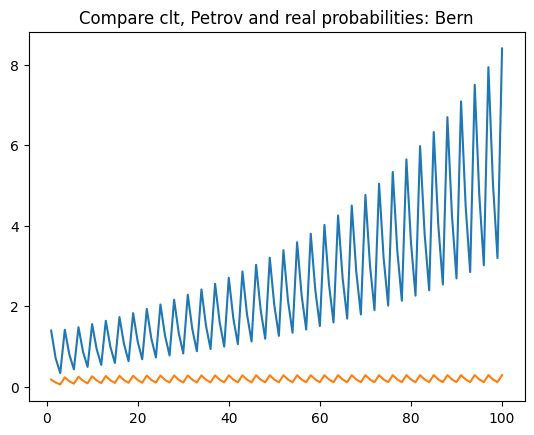

In [7]:
compare(prob_bern, clt_approx_bern, petrov_approx_bern, max_size = 100)
plt.title('Compare clt, Petrov and real probabilities: Bern')
plt.show()

In [ ]:
def check_ldt_bern(a = 0.06, num_sim = 10000, n = 100):
    # large deviation theory
    acceptance = 0
    cdl = []
    true = []
    for _ in range(num_sim):
        data = stats.binom.rvs(n = 1,p = 1/3, size = n)
        s = np.sum(data)
        cdl_pval = stats.ttest_1samp(data, 1/3)[1]
        true_pval = 1 - stats.binom.cdf(s, n = n, p = 1/3)
        cdl.append(cdl_pval)
        true.append(true_pval)
    sns.ecdfplot(cdl, label = 'CDL approx')
    sns.ecdfplot(true ,label = 'True p-value')
    x = np.linspace(0, 1, 100)
    #plt.plot(x,x, linestyle = '--', color= 'black')
    plt.legend()
    plt.show()

        




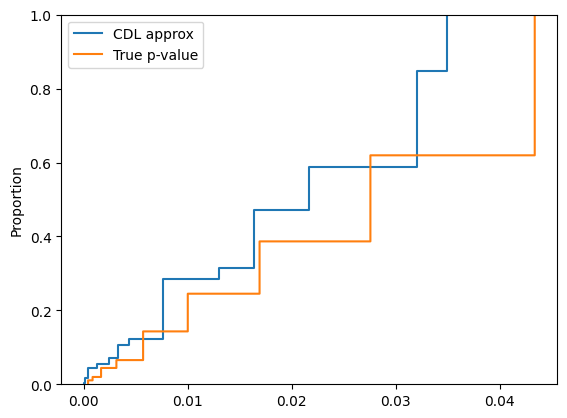

In [31]:
check_ldt_bern(a = 0.05)

In [23]:
def get_asymp_bern(num_sim = 1000, n_vals = [20, 30, 50, 100, 150]):
    len_n = len(n_vals)
    empirical_probs = np.zeros(len_n)
    for i, n in enumerate(n_vals):
        big = 0
        for sim in range(num_sim):
            x = stats.expon.rvs(size = n)
            s = np.sum(x)
            if s > 2*n/3:
                big+=1/num_sim
        empirical_probs[i] = big
    theoretical_probs = [3/(np.sqrt(np.pi*n)*np.log(2))*np.exp(-n*(np.log(2)/3)) for n in n_vals]
    plt.plot(n_vals, empirical_probs, marker='o', label = 'Empirical probs')
    plt.plot(n_vals, theoretical_probs, marker='o', label = 'Theoretical')
    plt.legend()
    plt.title("Asympthotic behaviour from Petrov's theorem : exp")
    plt.show()

![petrov asympthotic for bern](petrov_bern.png)

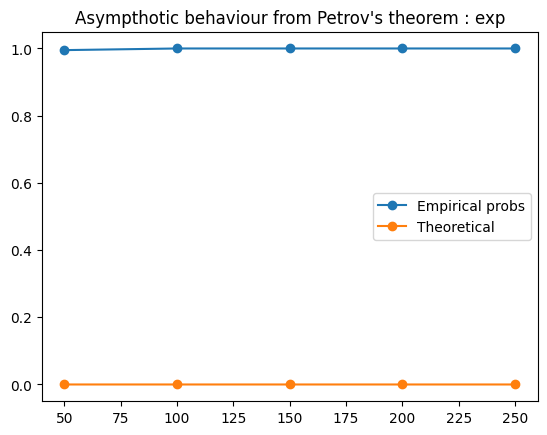

In [25]:
get_asymp_bern(10000, [50, 100, 150, 200, 250])

3. *Сгенерируем траектории блужданий из а) стандартного экспоненциального распределения, б) распределения Парето с параметром формы 3, в) величину с ф.р. 1 − e^(−x)/x^3, x ≥ 1. Отберем из траекторий
те, которые за n ходов оказываются выше 2nEX. Как выглядит их траектории, как они соотносятся с
“обычными траекториями” и какие соображения из теории больших уклонений они отражают?

In [39]:
def sim_rw(x_gen, num_steps = 100):
    x = x_gen(size = num_steps)
    s = np.cumsum(x)
    return x, s

def select_big(x_gen, mean, gen_name, num_sim = 5, num_steps = 20):
    selected = 0
    print(f'Expected mean = {mean}')
    num_iter = 0
    max_iter = 10000000000
    while selected < num_sim and num_iter < max_iter:
        x, s = sim_rw(x_gen, num_steps=num_steps)
        num_iter += 1
        if s[-1] >= 2*num_steps*mean:
            plt.plot(s)
            selected +=1
            print(f'\nParameters of selected path number {selected} : ')
            print(f'Mean step = {np.mean(x):.3f}')
            print(f'Max step = {np.max(x):.3f}')
            x = x[x != np.max(x)]
            print(f'Mean step without max = {np.mean(x):.3f}')
    if num_iter == max_iter:
        print(f'Max iterations reached')
    plt.title(f"Selcted trajectories for x ~ {gen_name}")
    plt.axhline(y = 2*num_steps*mean, linestyle='--', color= 'black', label = 'Treshhold')
    plt.legend()
    plt.show()
        



### Генераторы для задачи:

In [21]:
# stats.expon.rvs
# partial(stats.pareto.rvs, b = 3)
def x_gen3(size):
    x = np.zeros(size)
    count = 0

    while count < size:
        u = stats.uniform.rvs()
        if u > 1-1/np.e:
            while 1:
                y = stats.expon.rvs()
                u = stats.uniform.rvs()
                if u < (y+4)/(4*(1+y)**4):
                    x[count] = y+1
                    count += 1
                    break
        else:
            x[count] = 1
            count += 1
    return x


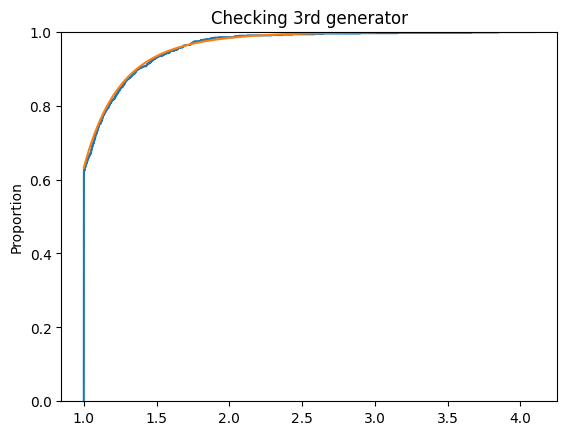

In [22]:
data = x_gen3(1000)
sns.ecdfplot(data)
x = np.linspace(1, 3, 1000)
plt.plot(x, 1-np.exp(-x)/x**3)
plt.title("Checking 3rd generator")
plt.show()

### Результаты

Expected mean = 1

Parameters of selected path number 1 : 
Mean step = 2.013
Max step = 9.888
Mean step without max = 1.742

Parameters of selected path number 2 : 
Mean step = 2.013
Max step = 5.321
Mean step without max = 1.898

Parameters of selected path number 3 : 
Mean step = 2.019
Max step = 7.733
Mean step without max = 1.822

Parameters of selected path number 4 : 
Mean step = 2.016
Max step = 8.210
Mean step without max = 1.802

Parameters of selected path number 5 : 
Mean step = 2.108
Max step = 9.632
Mean step without max = 1.848


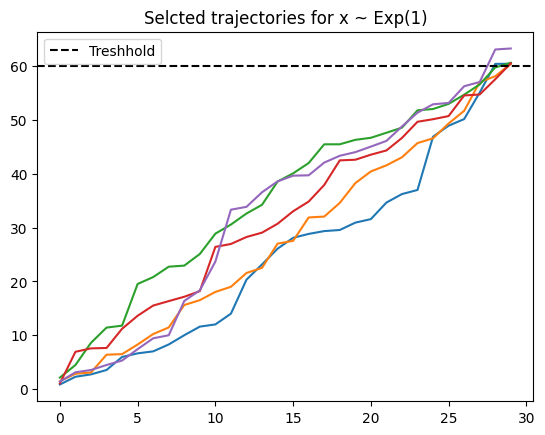

In [44]:
select_big(stats.expon.rvs, 1, 'Exp(1)', num_sim = 5, num_steps=30)

Expected mean = 1.5

Parameters of selected path number 1 : 
Mean step = 4.269
Max step = 83.100
Mean step without max = 1.551

Parameters of selected path number 2 : 
Mean step = 3.303
Max step = 60.963
Mean step without max = 1.315

Parameters of selected path number 3 : 
Mean step = 3.070
Max step = 49.050
Mean step without max = 1.484

Parameters of selected path number 4 : 
Mean step = 3.852
Max step = 64.288
Mean step without max = 1.768

Parameters of selected path number 5 : 
Mean step = 3.678
Max step = 68.645
Mean step without max = 1.437


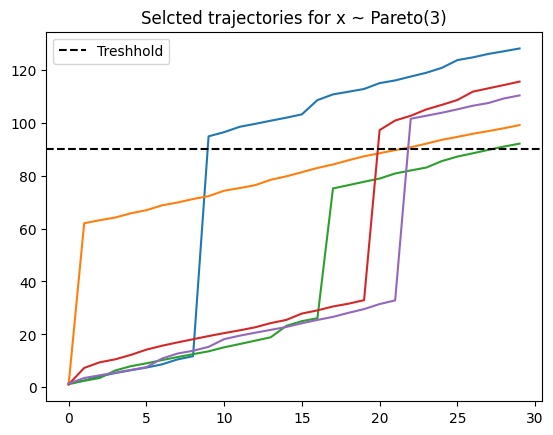

In [40]:
select_big(partial(stats.pareto.rvs, b = 3), 3/2, 'Pareto(3)', num_sim = 5, num_steps=30)

Expected mean = 1.1

Parameters of selected path number 1 : 
Mean step = 2.205
Max step = 6.903
Mean step without max = 1.030

Parameters of selected path number 2 : 
Mean step = 2.256
Max step = 4.278
Mean step without max = 1.750

Parameters of selected path number 3 : 
Mean step = 2.248
Max step = 5.662
Mean step without max = 1.395

Parameters of selected path number 4 : 
Mean step = 2.243
Max step = 6.188
Mean step without max = 1.257

Parameters of selected path number 5 : 
Mean step = 2.230
Max step = 4.935
Mean step without max = 1.554


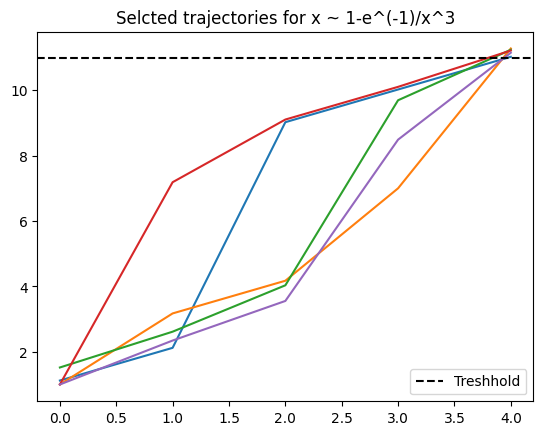

In [43]:
select_big(x_gen3, 1.1, '1-e^(-1)/x^3', num_sim = 5, num_steps=5)

4. Рассмотрим данные с функцией распределения F(x). Исследуйте последовательность нарастающих
частичных сумм Sn. Сходится ли Sn/√n? При каком α Sn/nα сходится к невырожденному пределу?
Моделируйте соответствующие данные и постройте гистограмму предельного распределения.
Всего нужно сделать 2 пункта, которые определяются так. Если длина имени четная, то берете a, иначе
b, если длина фамилии четная, то берете c, иначе d.

Задача на бонус по дополнительным главам: сравните результат с теоремой об устойчивых распределениях.

(b) F(x) = 1 − 1/(2x^3/2), x > 1, F(x) = 1/2(−x)^1/2, x < −1.

(d) F(x) = 1 − 1/(2x^3/2), x > 1, F(x) = 1/(2(−x)^3/2), x <−1.

пункты b и d

In [2]:
def model_b(size):
    data = np.zeros(size)
    # (b) F(x) = 1 − 1/(2x^3/2), x > 1, F(x) =  x < −1
    # F^-1(x) = ((1/(1-x))/2)**(2/3), x > 1/2
    # F^-1(x) = -(1/(2x))**2, x<1/2
    for i in range(size):
        x = stats.uniform.rvs()
        if x < 1/2:
            data[i] = -(1/(2*x))**2
        else:
            data[i] = ((1/(1-x))/2)**(2/3)
    return data
        

In [3]:
def model_d(size):
    data = np.zeros(size)
    # F(x) = 1 − 1/(2x^3/2), x > 1, F(x) = 1/(2(−x)^3/2), x < −1.
    # F^-1(x) = ((1/(1-x))/2)**(2/3), x > 1/2
    # F^-1(x) = -(1/(2x))**(2/3), x < 1/2
    for i in range(size):
        x = stats.uniform.rvs()
        if x < 1/2:
            data[i] = -(1/(2*x))**(2/3)
        else:
            data[i] = ((1/(1-x))/2)**(2/3)
    return data

Проверки генераторов

[ -1.94937167  -2.45079529   1.28502969   1.57626631   1.56606724
   1.26892163   2.30306634  -5.09114928   5.11223198  -1.505953
   1.12230185  -1.18606812  -1.67221944  -1.86957784   1.61776695
  -1.18883154   1.44633315   1.12304029   1.05292436  -2.44547261
  -1.0370986   13.91413946  -9.30703506   8.82034954   1.24207588
   1.26167468   3.7786965    1.91688217  -1.05015946  -1.36365211
   1.30190429   1.80738492   1.95342079   2.4951855    1.12354819
  -2.136828     1.86536618  13.20835683   2.00893733  -9.72361459
   3.44807731   2.59692993   5.80835432   1.4434713   -7.05583994
   1.70131384  -1.32778079   2.21996277   1.4893083   -2.94966059
   1.74850279   1.25877859   2.39839939 -25.98785079   6.62186896
   1.04202775  27.82121552  -5.70755452 -49.52161488  -1.02876089
   1.33083801  -1.78773004  -1.77704848   2.54109879   1.39935716
  -7.29881557   6.65617892   1.63371605  -1.36096483  -1.06701284
   7.02596384   3.16983413   4.2352635    1.10261168   1.78045201
  -1.8336981

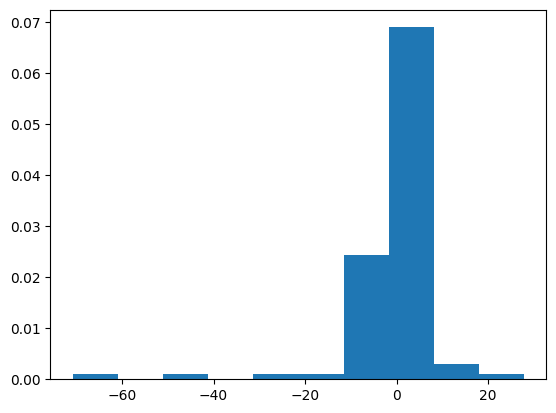

In [26]:
data = model_b(100)
data = data[data>-100]
plt.hist(data, density = True)
print(data)
#sns.ecdfplot(data)
x = np.linspace(-10, -1, 100)
#plt.plot(x, 1/(2*(-x)**0.5))
y = np.linspace(1,10, 100)
#plt.plot(y, 1 - 1/(2*y**1.5))
print(np.mean(data))

                  

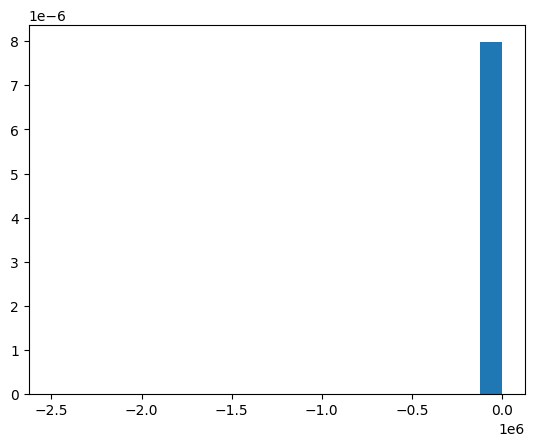

In [19]:
data = model_b(1000)
plt.hist(data, density =True,bins = 20);

In [48]:
def model_alpha(x_gen, alpha = 1/2, n = 1000, num_sim = 1000, cut  =False):
    normalized_sum = np.zeros(num_sim)
    for sim in range(num_sim):
        data = x_gen(size = n)
        s = np.sum(data)
        normalized_sum[sim] = s/(n**alpha)
    if cut:
        normalized_sum = normalized_sum[normalized_sum > -50]
    plt.hist(normalized_sum, density=True, label = f"alpha = {alpha}", alpha = 0.3)
    #plt.legend()
    #plt.show()

In [5]:
def find_alpha(x_gen, alpha_range = [0, 2], n = 100, num_sim  = 100, step = 10):
    alpha_vals = [alpha_range[0]+ i*(alpha_range[1]- alpha_range[0])/step for i in range(step+1)]
    var = np.zeros(step+1)
    for i, alpha in enumerate(alpha_vals):
        normalized = np.zeros(num_sim)
        for sim in range(num_sim):
            x = x_gen(size = n)
            s = np.sum(x)
            normalized[sim] = s/(n**alpha)
        var[i] = np.var(normalized)
    plt.plot(alpha_vals, var, marker='o', label = 'Empirical variance')
    plt.legend()
    plt.show()


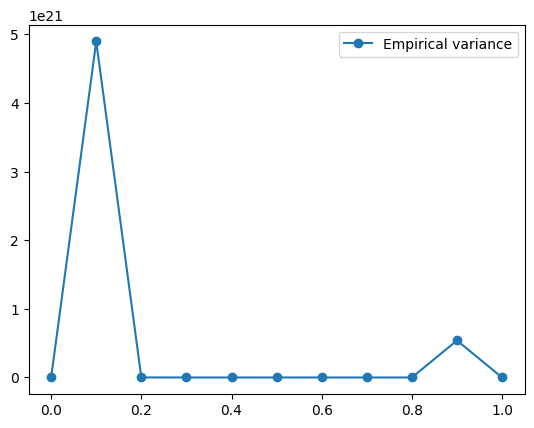

In [39]:
find_alpha(model_b, [0,1], num_sim = 1000, step = 10)

In [37]:
def model_b_exp(size):
    return np.exp(model_b(size))

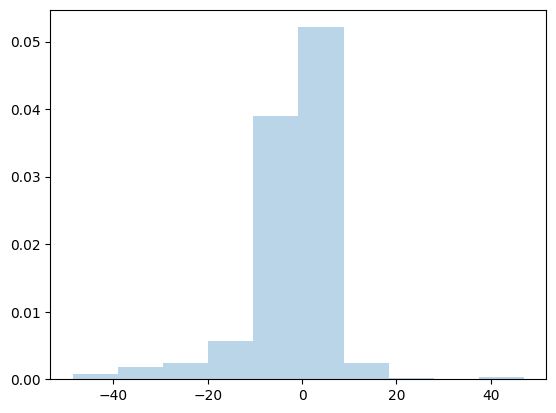

In [58]:
model_alpha(model_b, alpha = 0, n = 1, cut = True)

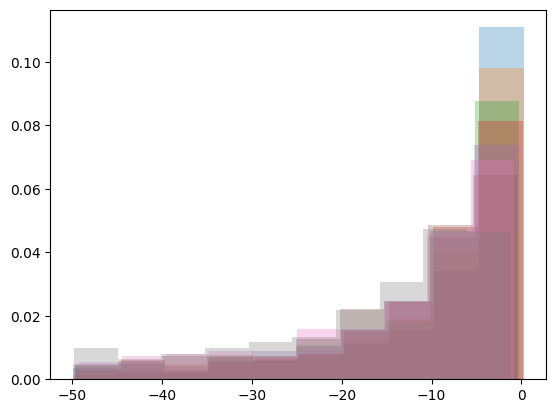

In [55]:
n_vals = [50,100,150, 200, 300, 400, 500, 1000]
for n in n_vals:
    model_alpha(model_b, alpha = 1.5, n = n, cut = True)

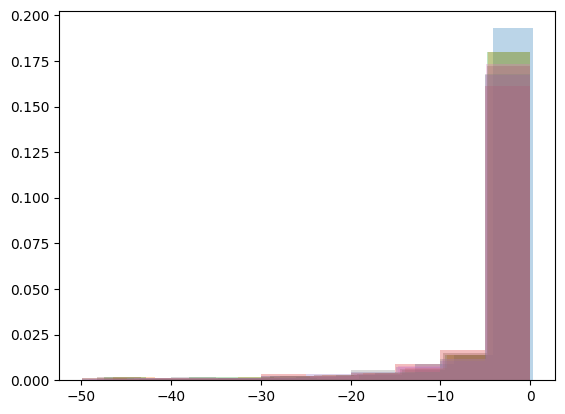

In [59]:
n_vals = [50,100,150, 200, 300, 400, 500, 1000]
for n in n_vals:
    model_alpha(model_b, alpha = 2, n = n, cut = True)

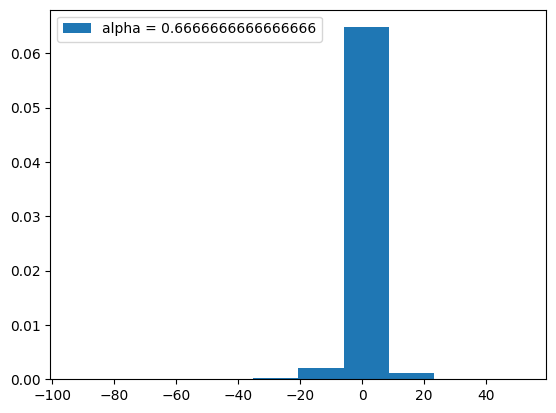

In [6]:
model_alpha(model_d, alpha=2/3, n = 1000)